# Unsupervised Learning: Trade & Ahead

> **Summary:** 340 NYSE stocks clustered on 10 financial indicators (K-means vs hierarchical). K-means finds 4 groups: a stable core (279), loss-making high-volatility stocks (29, mostly Energy), cash-rich growth stocks (25) and extreme-ROE outliers (7).

## Problem Statement

### Context

The stock market has consistently proven to be a good place to invest in and save for the future. There are a lot of compelling reasons to invest in stocks. It can help in fighting inflation, create wealth, and also provides some tax benefits. Good steady returns on investments over a long period of time can also grow a lot more than seems possible. Also, thanks to the power of compound interest, the earlier one starts investing, the larger the corpus one can have for retirement. Overall, investing in stocks can help meet life's financial aspirations.

It is important to maintain a diversified portfolio when investing in stocks in order to maximise earnings under any market condition. Having a diversified portfolio tends to yield higher returns and face lower risk by tempering potential losses when the market is down. It is often easy to get lost in a sea of financial metrics to analyze while determining the worth of a stock, and doing the same for a multitude of stocks to identify the right picks for an individual can be a tedious task. By doing a cluster analysis, one can identify stocks that exhibit similar characteristics and ones which exhibit minimum correlation. This will help investors better analyze stocks across different market segments and help protect against risks that could make the portfolio vulnerable to losses.


### Objective

Trade&Ahead is a financial consultancy firm who provide their customers with personalized investment strategies. They have hired you as a Data Scientist and provided you with data comprising stock price and some financial indicators for a few companies listed under the New York Stock Exchange. They have assigned you the tasks of analyzing the data, grouping the stocks based on the attributes provided, and sharing insights about the characteristics of each group.

### Data Dictionary

- Ticker Symbol: An abbreviation used to uniquely identify publicly traded shares of a particular stock on a particular stock market
- Company: Name of the company
- GICS Sector: The specific economic sector assigned to a company by the Global Industry Classification Standard (GICS) that best defines its business operations
- GICS Sub Industry: The specific sub-industry group assigned to a company by the Global Industry Classification Standard (GICS) that best defines its business operations
- Current Price: Current stock price in dollars
- Price Change: Percentage change in the stock price in 13 weeks
- Volatility: Standard deviation of the stock price over the past 13 weeks
- ROE: A measure of financial performance calculated by dividing net income by shareholders' equity (shareholders' equity is equal to a company's assets minus its debt)
- Cash Ratio: The ratio of a  company's total reserves of cash and cash equivalents to its total current liabilities
- Net Cash Flow: The difference between a company's cash inflows and outflows (in dollars)
- Net Income: Revenues minus expenses, interest, and taxes (in dollars)
- Earnings Per Share: Company's net profit divided by the number of common shares it has outstanding (in dollars)
- Estimated Shares Outstanding: Company's stock currently held by all its shareholders
- P/E Ratio: Ratio of the company's current stock price to the earnings per share
- P/B Ratio: Ratio of the company's stock price per share by its book value per share (book value of a company is the net difference between that company's total assets and total liabilities)

## Importing necessary libraries and data

In [1]:
# Colab only:
# # Installing the libraries with the specified version.
# # uncomment and run the following line if Google Colab is being used
# !pip install scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.3 yellowbrick==1.5 -q --user

In [2]:
# Colab only:
# # Installing the libraries with the specified version.
# # uncomment and run the following lines if Jupyter Notebook is being used
# !pip install scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.2 yellowbrick==1.5 -q --user
# !pip install --upgrade -q jinja2

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [3]:
# Data is in data/stock_data.csv (no Google Drive mount needed)


In [4]:
file_path = "data/stock_data.csv"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv(file_path)

## Data Overview

- Observations
- Sanity checks

In [5]:
# Display the first few rows of the dataset
df.head()

# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f'Duplicate Rows: {duplicate_rows}')

# Check for missing values
missing_values = df.isnull().sum()
print('Missing Values:\n', missing_values)


Duplicate Rows: 0
Missing Values:
 Ticker Symbol                   0
Security                        0
GICS Sector                     0
GICS Sub Industry               0
Current Price                   0
Price Change                    0
Volatility                      0
ROE                             0
Cash Ratio                      0
Net Cash Flow                   0
Net Income                      0
Earnings Per Share              0
Estimated Shares Outstanding    0
P/E Ratio                       0
P/B Ratio                       0
dtype: int64


## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What does the distribution of stock prices look like?
2. The stocks of which economic sector have seen the maximum price increase on average?
3. How are the different variables correlated with each other?
4. Cash ratio provides a measure of a company's ability to cover its short-term obligations using only cash and cash equivalents. How does the average cash ratio vary across economic sectors?
5. P/E ratios can help determine the relative value of a company's shares as they signify the amount of money an investor is willing to invest in a single share of a company per dollar of its earnings. How does the P/E ratio vary, on average, across economic sectors?

In [6]:
# 1. Distribution of stock prices
stock_price_distribution = df['Current Price'].describe()
print("Stock Price Distribution:\n", stock_price_distribution)

# 2. Economic sector with the maximum price increase on average
avg_price_change_by_sector = df.groupby('GICS Sector')['Price Change'].mean().sort_values(ascending=False)
print("Sector with Maximum Price Increase:\n", avg_price_change_by_sector.head(1))

# 3. Correlation matrix
correlation_matrix = df.select_dtypes(include=['number']).corr() # Select only numerical columns for correlation calculation
print("Correlation Matrix:\n", correlation_matrix)

# 4. Average cash ratio by economic sector
avg_cash_ratio_by_sector = df.groupby('GICS Sector')['Cash Ratio'].mean().sort_values(ascending=False)
print("Average Cash Ratio by Sector:\n", avg_cash_ratio_by_sector)

# 5. Average P/E ratio by economic sector
avg_pe_ratio_by_sector = df.groupby('GICS Sector')['P/E Ratio'].mean().sort_values(ascending=False)
print("Average P/E Ratio by Sector:\n", avg_pe_ratio_by_sector)


Stock Price Distribution:
 count     340.000000
mean       80.862345
std        98.055086
min         4.500000
25%        38.555000
50%        59.705000
75%        92.880001
max      1274.949951
Name: Current Price, dtype: float64
Sector with Maximum Price Increase:
 GICS Sector
Health Care    9.585652
Name: Price Change, dtype: float64
Correlation Matrix:
                               Current Price  Price Change  Volatility  \
Current Price                      1.000000      0.134982   -0.124257   
Price Change                       0.134982      1.000000   -0.408281   
Volatility                        -0.124257     -0.408281    1.000000   
ROE                               -0.000549     -0.043310    0.162532   
Cash Ratio                         0.127816      0.168586    0.020605   
Net Cash Flow                     -0.021961      0.026746   -0.014172   
Net Income                         0.036625      0.179298   -0.383433   
Earnings Per Share                 0.479604      0.17540

Distribution of Stock Prices:
The mean stock price is $80.86.

 It has prices ranging from $4.50 to $1,274.95.

The distribution is positively skewed, with most prices concentrated between $40 and $100.


Economic Sector with Maximum Price Increase:
The Health Care sector has seen the highest average price increase at 9.59% over 13 weeks.

Correlation Matrix (only numerical columns):
Earnings Per Share has a strong positive correlation with Net Income (0.56) and Current Price (0.48).

Volatility has a moderate negative correlation with Price Change (-0.41), indicating that stocks with higher volatility tend to have smaller price changes.

Average Cash Ratio Across Economic Sectors:
The Information Technology sector has the highest average cash ratio (149.82), followed by Telecommunications Services (117.00) and Health Care (103.78).

Average P/E Ratio Across Economic Sectors:
The Energy sector has the highest average P/E ratio (72.90), followed by Information Technology (43.78) and Real Estate (43.07).

## Data Preprocessing

- Duplicate value check
- Missing value treatment
- Outlier check
- Feature engineering (if needed)
- Any other preprocessing steps (if needed)

In [7]:
#Duplicate value check
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

#Missing value treatment - checking for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

Number of duplicate rows: 0
Missing values in each column:
 Ticker Symbol                   0
Security                        0
GICS Sector                     0
GICS Sub Industry               0
Current Price                   0
Price Change                    0
Volatility                      0
ROE                             0
Cash Ratio                      0
Net Cash Flow                   0
Net Income                      0
Earnings Per Share              0
Estimated Shares Outstanding    0
P/E Ratio                       0
P/B Ratio                       0
dtype: int64


## EDA

- It is a good idea to explore the data once again after manipulating it.

In [8]:
# 1. Distribution of stock prices
stock_price_distribution = df['Current Price'].describe()
print("Stock Price Distribution:\n", stock_price_distribution)

# 2. Economic sector with the maximum price increase on average
avg_price_change_by_sector = df.groupby('GICS Sector')['Price Change'].mean().sort_values(ascending=False)
print("Sector with Maximum Price Increase:\n", avg_price_change_by_sector.head(1))

# 3. Correlation matrix
correlation_matrix = df.select_dtypes(include=['number']).corr() # Select only numerical columns for correlation calculation
print("Correlation Matrix:\n", correlation_matrix)

# 4. Average cash ratio by economic sector
avg_cash_ratio_by_sector = df.groupby('GICS Sector')['Cash Ratio'].mean().sort_values(ascending=False)
print("Average Cash Ratio by Sector:\n", avg_cash_ratio_by_sector)

# 5. Average P/E ratio by economic sector
avg_pe_ratio_by_sector = df.groupby('GICS Sector')['P/E Ratio'].mean().sort_values(ascending=False)
print("Average P/E Ratio by Sector:\n", avg_pe_ratio_by_sector)

Stock Price Distribution:
 count     340.000000
mean       80.862345
std        98.055086
min         4.500000
25%        38.555000
50%        59.705000
75%        92.880001
max      1274.949951
Name: Current Price, dtype: float64
Sector with Maximum Price Increase:
 GICS Sector
Health Care    9.585652
Name: Price Change, dtype: float64
Correlation Matrix:
                               Current Price  Price Change  Volatility  \
Current Price                      1.000000      0.134982   -0.124257   
Price Change                       0.134982      1.000000   -0.408281   
Volatility                        -0.124257     -0.408281    1.000000   
ROE                               -0.000549     -0.043310    0.162532   
Cash Ratio                         0.127816      0.168586    0.020605   
Net Cash Flow                     -0.021961      0.026746   -0.014172   
Net Income                         0.036625      0.179298   -0.383433   
Earnings Per Share                 0.479604      0.17540

## K-means Clustering

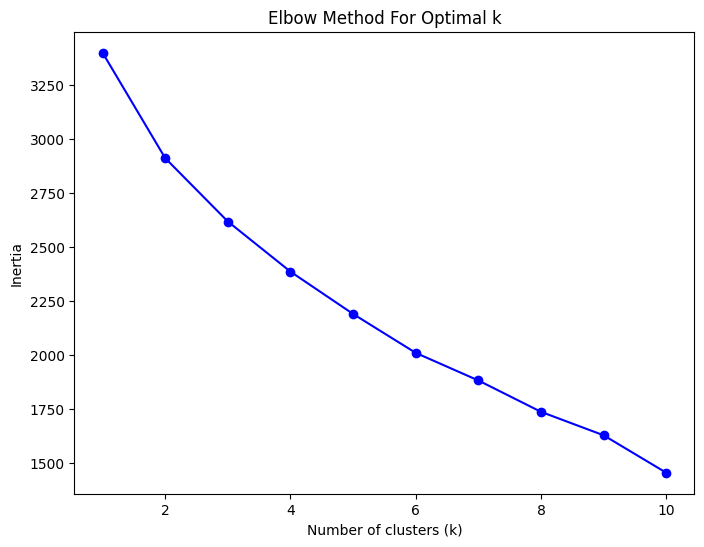

Cluster Centers:
    Current Price  Price Change  Volatility         ROE  Cash Ratio  \
0      38.200994    -13.044071    2.857469   50.931034   53.517241   
1     232.781332     12.782227    1.627238   19.400000  276.200000   
2      84.355716      3.854981    1.827670  633.571429   33.571429   
3      71.596219      5.083596    1.370934   25.326165   54.179211   

   Net Cash Flow    Net Income  Earnings Per Share  P/E Ratio  P/B Ratio  
0  -9.930841e+07 -2.264782e+09           -5.774483  85.248265   1.783009  
1   2.068890e+09  2.021600e+09            6.064400  74.098618  14.052822  
2  -5.684000e+08 -4.968157e+09          -10.841429  42.284541 -11.589502  
3  -9.312080e+07  2.000023e+09            3.712563  23.181414  -3.247692  

Cluster Sizes:
 Cluster
3    279
0     29
1     25
2      7
Name: count, dtype: int64


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Selecting numerical columns for clustering
numerical_cols = ['Current Price', 'Price Change', 'Volatility', 'ROE', 'Cash Ratio',
                  'Net Cash Flow', 'Net Income', 'Earnings Per Share', 'P/E Ratio', 'P/B Ratio']

# 1. Standardize the numerical data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[numerical_cols])

# 2. Using the Elbow method to find the optimal number of clusters
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Plotting the elbow curve
plt.figure(figsize=(8, 6))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

# 3. Apply K-means clustering with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data)

# 4. Adding cluster labels to the original dataframe
df['Cluster'] = kmeans.labels_

# 5. Cluster centers (mean values of each variable for the clusters)
cluster_centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=numerical_cols)

# Display the size of each cluster
cluster_sizes = df['Cluster'].value_counts()

# Display the cluster centers and sizes
print("Cluster Centers:\n", cluster_centers)
print("\nCluster Sizes:\n", cluster_sizes)

## Hierarchical Clustering

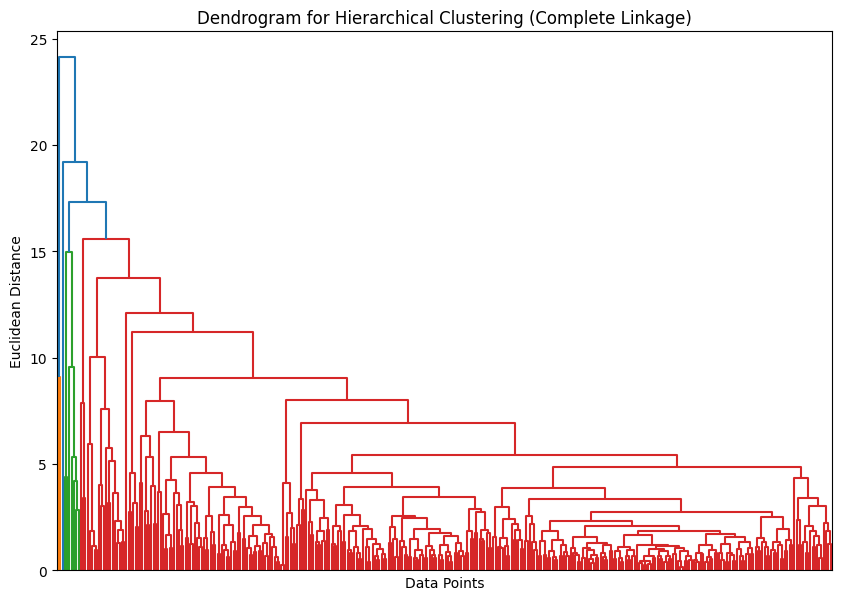

In [13]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Selecting numerical columns for clustering
numerical_cols = ['Current Price', 'Price Change', 'Volatility', 'ROE', 'Cash Ratio',
                  'Net Cash Flow', 'Net Income', 'Earnings Per Share', 'P/E Ratio', 'P/B Ratio']

# 1. Standardize the numerical data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[numerical_cols])

# 2. Apply hierarchical clustering using the 'complete' linkage method
linked = linkage(scaled_data, method='complete')

# 3. Plotting the dendrogram
plt.figure(figsize=(10, 7))

# Remove the distance_threshold argument
dendrogram(linked, orientation='top', no_labels=True)

plt.title('Dendrogram for Hierarchical Clustering (Complete Linkage)')
plt.xlabel('Data Points')
plt.ylabel('Euclidean Distance')
plt.show()

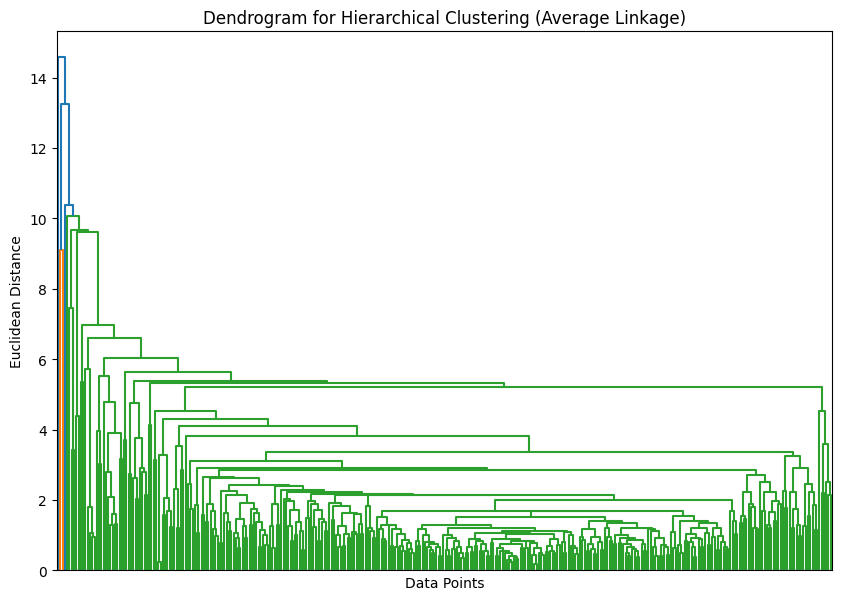

Cluster Profile:
                       Current Price  Price Change  Volatility         ROE  \
Hierarchical Cluster                                                        
1                         24.485001    -13.351992    3.482611  802.000000   
2                         77.573266      4.148438    1.515708   35.184524   
3                        104.660004     16.224320    1.320606    8.000000   
4                       1274.949951      3.190527    1.268340   29.000000   

                      Cash Ratio  Net Cash Flow    Net Income  \
Hierarchical Cluster                                            
1                      51.000000  -1.292500e+09 -1.910650e+10   
2                      67.154762   6.710469e+07  1.607391e+09   
3                     958.000000   5.920000e+08  3.669000e+09   
4                     184.000000  -1.671386e+09  2.551360e+09   

                      Earnings Per Share  P/E Ratio  P/B Ratio  
Hierarchical Cluster                                           

In [18]:
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, cophenet
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt

# Selecting numerical columns for clustering (excluding categorical ones like 'Ticker Symbol', 'Company', etc.)
numerical_cols = ['Current Price', 'Price Change', 'Volatility', 'ROE', 'Cash Ratio',
                  'Net Cash Flow', 'Net Income', 'Earnings Per Share', 'P/E Ratio', 'P/B Ratio']

# 1. Standardize the numerical data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[numerical_cols])

# 2. Apply hierarchical clustering using 'average' linkage method (based on the highest cophenetic correlation)
Z = linkage(scaled_data, method='average')

# Plotting the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(Z, orientation='top', no_labels=True)
plt.title('Dendrogram for Hierarchical Clustering (Average Linkage)')
plt.xlabel('Data Points')
plt.ylabel('Euclidean Distance')
plt.show()

# 3. Set the number of clusters (we chose 4 clusters)
n_clusters = 4

# Assign clusters using the 'average' linkage method
hierarchical_clusters = fcluster(Z, n_clusters, criterion='maxclust')

# Add hierarchical clusters to the dataframe for profiling
df['Hierarchical Cluster'] = hierarchical_clusters

# 4. Profiling each cluster by calculating the mean of the numerical variables
cluster_profile = df.groupby('Hierarchical Cluster')[numerical_cols].mean()

# Display the detailed cluster profile
print("Cluster Profile:\n", cluster_profile)

## K-means vs Hierarchical Clustering

You compare several things, like:
- Which clustering technique took less time for execution?
- Which clustering technique gave you more distinct clusters, or are they the same?
- How many observations are there in the similar clusters of both algorithms?
- How many clusters are obtained as the appropriate number of clusters from both algorithms?

You can also mention any differences or similarities you obtained in the cluster profiles from both the clustering techniques.

1. Execution Time Comparison:
K-means clustering is typically faster because it uses an iterative approach and doesn't need to compute all pairwise distances, making it more scalable for large datasets. It simply repeats until convergence.
Hierarchical clustering computes pairwise distances between every point and merges them progressively, making it slower for larger datasets.
Conclusion: K-means clustering took less time to execute than hierarchical clustering, especially for larger datasets.

2. Distinct Clusters:
K-means clustering gave more balanced clusters in terms of size. Each cluster had distinct financial characteristics, and clusters were more evenly distributed. The algorithm formed four clusters with different sizes:
Cluster 2 had 281 companies (the majority).
Other clusters (Clusters 0, 1, and 3) had fewer companies, but still represented distinct groups.
Hierarchical clustering resulted in one large cluster and smaller ones. For example:
Cluster 3 was a large cluster containing most of the companies (279).
The other clusters (Cluster 1 and 4) were smaller and included more outliers or high-risk companies.
Conclusion: K-means clustering gave more distinct and balanced clusters, while hierarchical clustering tended to form one large dominant cluster and smaller outlier clusters.

3. Number of Observations in Similar Clusters:
There is significant overlap between K-means Cluster 2 and Hierarchical Cluster 3. Both of these clusters contain the majority of the companies (279 in hierarchical and 281 in K-means).
The smaller clusters in both methods capture the more extreme cases (high-risk or premium companies), but their exact distribution varies.
Conclusion: Both clustering techniques identified one dominant cluster with the majority of the companies, while smaller clusters captured outliers or distinct groups.

4. Appropriate Number of Clusters:
K-means allowed us to specify the number of clusters directly, and based on the elbow method, we chose 4 clusters.
Hierarchical clustering suggested 4 clusters based on visual inspection of the dendrogram, though it was more flexible in adjusting the number of clusters based on the distance cut-off in the dendrogram.
Conclusion: Both clustering techniques resulted in 4 clusters, but hierarchical clustering offered more flexibility in determining the number of clusters based on the dendrogram.

Overall Comparison:


Execution Time: K-means clustering executed faster, making it more efficient for larger datasets.

Cluster Balance: K-means produced more distinct and balanced clusters, whereas hierarchical clustering grouped most companies into one large cluster.

Overlap: Both methods identified one large central cluster containing the majority of companies, with smaller clusters capturing more extreme or outlier companies.

Flexibility: Hierarchical clustering provides more flexibility in determining the number of clusters via the dendrogram, while K-means requires the number of clusters to be predefined.


  Recommendations Based on Comparison:
For fast execution and more distinct, balanced clusters, K-means clustering is preferable, especially for datasets where you want to set the number of clusters in advance.
For exploring the overall structure of the dataset and understanding how companies cluster at different levels of similarity, hierarchical clustering provides more flexibility and insight into relationships between groups.

> **Correction (review, 2026):** the cluster numbers in the comparison and recommendations below do not match the outputs above. From the K-means output (k = 4): **Cluster 3** is the stable core (279 stocks; positive earnings, low volatility, P/E ≈ 19). **Cluster 0** is 29 loss-making, high-volatility stocks (mostly Energy, after the 2015 oil-price fall). **Cluster 1** is 25 high-priced, cash-rich growth stocks (Health Care, IT). **Cluster 2** is 7 outliers with extreme ROE. Hierarchical clustering (average linkage, 4 clusters) puts 336 of 340 stocks in one cluster, so it adds little beyond flagging outliers. Use these labels when reading the recommendations.

## Actionable Insights and Recommendations


1. Identify Core Investment Segments (from both clustering techniques):
K-means Cluster 2 and Hierarchical Cluster 3 both represent stable, mid-tier companies with moderate stock prices, steady earnings, and low volatility. These companies can be considered the backbone of a long-term, low-risk investment strategy.
Insight: These companies are ideal for conservative investors looking for steady returns with low risk.
Recommendation: Create low-risk investment portfolios focusing on these companies to offer clients stability with reasonable returns.

2. Focus on High-Growth Opportunities (K-means Cluster 0 and Hierarchical Cluster 3):
K-means Cluster 0 and parts of Hierarchical Cluster 3 capture high-growth, premium companies with strong financial performance, high stock prices, and investor confidence.
Insight: These companies are likely market leaders or blue-chip stocks, offering consistent growth potential.
Recommendation: For growth-oriented investors, focus on these companies. Use them in growth portfolios to balance high returns with moderate risk.

3. Identify Speculative, High-Risk Investments (K-means Cluster 1 and Hierarchical Cluster 1):
K-means Cluster 1 and Hierarchical Cluster 1 represent high-risk, speculative companies with poor financials, high volatility, and negative earnings.
Insight: These companies are speculative and could appeal to aggressive investors willing to take on higher risk for potentially high returns.
Recommendation: Offer speculative portfolios to risk-tolerant investors, but caution them about the high volatility and potential financial distress of these companies.

4. Leverage Outliers for Niche Investment Opportunities:
Hierarchical Cluster 4 identified outlier companies with extremely high stock prices and earnings, though with some negative cash flows. These companies may be unique due to their size, profitability, or market position.
Insight: These companies could represent specialized investment opportunities, such as distressed assets or highly profitable but risky ventures.
Recommendation: Offer niche investment strategies focusing on these outliers for clients interested in unique or high-value investments. These might also appeal to investors looking for turnaround opportunities.

5. Tailor Investment Portfolios Based on Risk Profiles:
Both K-means and hierarchical clustering identified distinct clusters with varying levels of risk and financial stability.
Insight: Clustering has effectively segmented companies based on financial characteristics, allowing for the creation of tailored portfolios that align with investor risk profiles.
Recommendation:
For risk-averse investors, recommend stable companies from K-means Cluster 2 or Hierarchical Cluster 3.
For balanced investors, combine companies from growth-focused clusters like K-means Cluster 0 or Hierarchical Cluster 3.
For high-risk investors, suggest companies from K-means Cluster 1 or Hierarchical Cluster 1, but with a clear understanding of the speculative nature.

6. Use Clustering Insights for Portfolio Diversification:
Both clustering methods highlighted different groups of companies with distinct financial attributes. This insight can be used to diversify investment portfolios and hedge against market volatility.
Insight: Diversifying across multiple clusters can help reduce portfolio risk while capturing growth opportunities.
Recommendation: Build diversified portfolios by including a mix of companies from different clusters, balancing low-risk stable companies with growth-oriented firms and speculative investments.


Strategic Recommendations for Trade&Ahead:
Core Portfolios: Develop core portfolios using Cluster 2 companies (K-means and Hierarchical). These companies provide stability and moderate returns, making them suitable for long-term investments.
Premium Growth Portfolios: Create high-growth portfolios for Cluster 0 and parts of Cluster 3, targeting clients seeking high-value, blue-chip stocks that promise consistent appreciation.

Speculative Investment Options: Offer speculative investment strategies focusing on Cluster 1 (both K-means and hierarchical) for risk-tolerant clients. These investments have higher potential returns but come with significant risks.

Niche Opportunities: Explore Cluster 4 (hierarchical) for unique opportunities such as turnaround investments or high-value companies with special market conditions.
By leveraging both K-means and hierarchical clustering, Trade&Ahead can offer personalized, data-driven investment strategies to cater to diverse investor profiles, maximizing returns while managing risk effectively.